In [1]:
import numpy as np
import matplotlib.pylab as plt

In [5]:
#Take variables from Block_ files
# %store -r lsCGTBl1
# %store -r lsCGTBl5
%store -r lsCGTBl10
# %store -r lsCGTBl50

In [3]:
ls = [lsCGTBl1, lsCGTBl5, lsCGTBl10, lsCGTBl50]
config = ['1', '5', '10', '50']

## High T Behavior

In [4]:
# Theory
x = np.linspace(0.1, 30)
y = 1 / np.tanh(x) - 1 / x

#Critical temperature (Gihwan's data)
Tc = [0.41, 0.85, 1.09, 1.6]

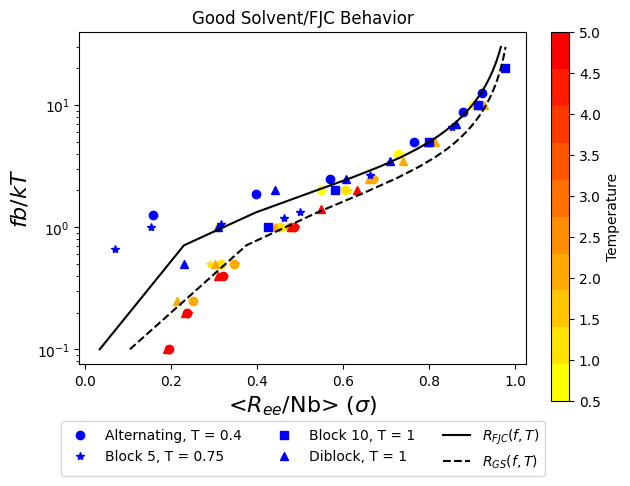

In [76]:
#High T behavior
import matplotlib as mpl

symbol = ['o','*', 's', '^']
sequence = ['Alternating', 'Block 5', 'Block 10', 'Diblock']

cmap = plt.get_cmap('autumn_r', 10)
norm = mpl.colors.Normalize(0.5, 5)

fig, ax = plt.subplots(layout='constrained')
T_theta = [0.4, 0.75, 1, 1]

for i in range(0, 4):
    cgt = ls[i]
    force = np.array([])
    Ree = np.array([])    

    for test in cgt:
        if test.t > Tc[i]:
            n_T = norm(test.t)
            Ree = test.aveRee
            force = test.f
            ax.plot((Ree / 99), force/test.t, symbol[i], color=cmap(n_T))


for i in range(0, 4):
    for cgt in ls[i]:
        if cgt.t == T_theta[i]:
            plt.plot(cgt.aveRee / 99, cgt.f/cgt.t, symbol[i], color = 'blue', label = f'{sequence[i]}, T = {T_theta[i]}')

#FJC and real chain models
plt.plot(y, x, 'k', label = '$R_{FJC}(f, T)$')
plt.plot(y**(2/3), x, 'k--', label = '$R_{GS}(f, T)$')

sm = mpl.cm.ScalarMappable(norm=norm, cmap=cmap)
plt.colorbar(sm, ax=ax, label = 'Temperature', fraction = 0.05)
box = ax.get_position()
ax.set_position([box.x0, box.y0 + box.height * 0.1,box.width, box.height * 0.9])
ax.legend(loc='upper center', bbox_to_anchor=(0.5, -0.15),fancybox=True, ncol=3)
plt.ylabel('$fb/kT$', fontsize=16)
plt.xlabel('<$R_{ee}$/Nb> ($\sigma$)', fontsize=16)
plt.yscale('log')
plt.title(r'Good Solvent/FJC Behavior')
plt.show()

## Free Energy

In [6]:
%store -r FE
%store -r FE_10

Text(87.72222222222221, 0.5, 'F$(\\epsilon)$')

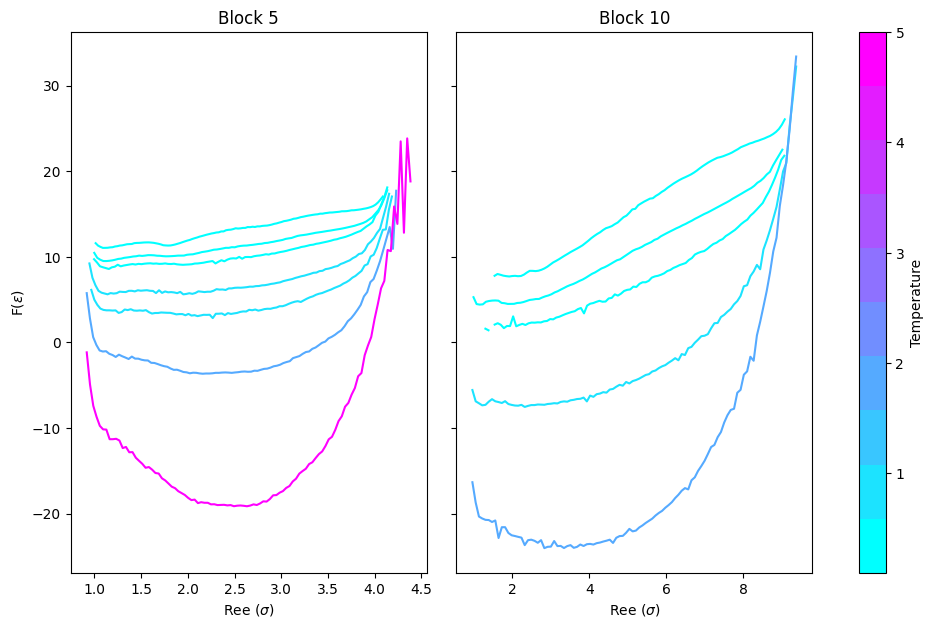

In [47]:
import matplotlib as mpl
fig, ax = plt.subplots(nrows = 1, ncols= 2, figsize = (10, 6), sharey=True)
fig.tight_layout()
cmap_FE = plt.get_cmap('cool', 10)
norm = mpl.colors.Normalize(0.1, 5)

#Block 5
c = np.array([-1, 0, 1, 1, 0, 0, -5])-10
T = np.array([0.1, 0.3, 0.5, 0.75, 1, 2, 5])
n_T = norm(T)
for i in range(7):
    ax[0].plot(FE[i][0],FE[i][1]-c[i], color = cmap_FE(n_T[i]))

#Block 10
c = [-7, -5, 1, 4, 11]
T = [0.1, 0.3, 0.5, 1, 2]
n_T = norm(T)
for i in range(5):
    ax[1].plot(FE_10[i][0],FE_10[i][1]-c[i], color = cmap_FE(n_T[i]))

sm = mpl.cm.ScalarMappable(cmap=cmap_FE, norm=norm)
plt.colorbar(sm, ax=ax, label='Temperature')
ax[0].set_title('Block 5')
ax[1].set_title('Block 10')
ax[0].set_xlabel('Ree $(\sigma)$')
ax[1].set_xlabel('Ree $(\sigma)$')
ax[0].set_ylabel('F$(\epsilon)$')

## Time Correlation

In [8]:
#Get segmental end-to-end distance
def segRee(D, Blck, Atom_Type):
    Nf = D.shape[0]
    Mseg = 100//Blck*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,Blck,9) #exclude first frame

    Xseg = D[:,:,:,3:6]

    if(Atom_Type == 'Hydrophilic'):
        # Get just the odd segments (hydrophilic segments)
        Xhp =  Xseg[:,1::2,:,:]
    elif(Atom_Type == 'Hydrophobic'):
        # Get just the even segments (hydrophobic segments)
        Xhp =  Xseg[:,0::2,:,:]
    
    # End-to-End vectors of the segments
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)
    return Rhp

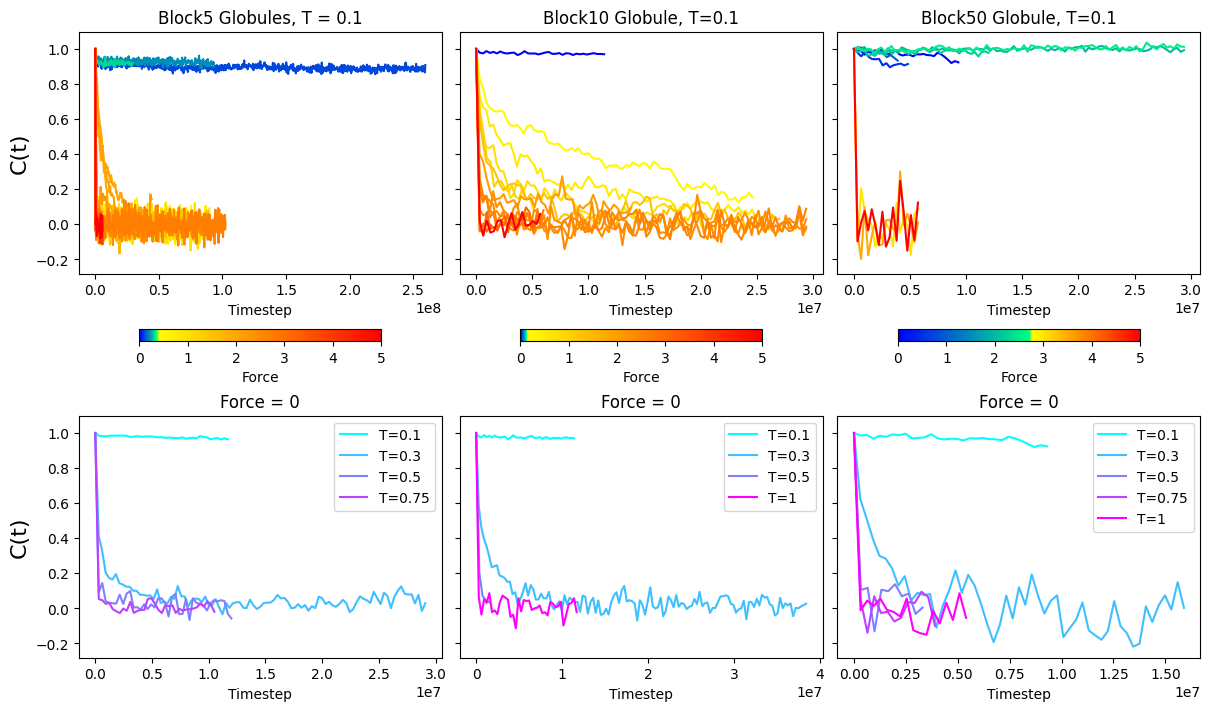

In [6]:
import matplotlib.colors as mcolors
import matplotlib as mpl

fig, ax = plt.subplots(nrows = 2, ncols= 3, figsize = (12, 7), sharey=True, layout='constrained')

CGT01 = lsCGTBl5[0]
# sample the colormaps that you want to use. Use 128 from each so we get 256
# colors in total
colors1 = plt.cm.winter(np.linspace(0, 1, 8))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 92))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

i = 0
for D in CGT01.ParsedRee[0:4]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,0].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1

i = 4
for D in CGT01.ParsedRee[4:]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,0].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0,0], label = 'Force', orientation = 'horizontal', fraction = 0.05)
ax[0,0].set_title('Block5 Globules, T = 0.1')
ax[0,0].set_xlabel('Timestep')
ax[0,0].set_ylabel('C(t)', fontsize = 16)

#Block10
CGT01 = lsCGTBl10[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 25))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 975))
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

i = 0
for D in CGT01.ParsedRee[0:1]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,1].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1

i = 1
for D in CGT01.ParsedRee[1:]:
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,1].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0], color = mymap(n_f[i]))
    i += 1


sm = mpl.cm.ScalarMappable(norm=mpl.colors.Normalize(0, 5), cmap=mymap)
plt.colorbar(sm, ax=ax[0,1], label = 'Force', orientation = 'horizontal', fraction = 0.05)
ax[0,1].set_title('Block10 Globule, T=0.1')
ax[0,1].set_xlabel('Timestep')

#Block50
CGT01 = lsCGTBl50[0]
colors1 = plt.cm.winter(np.linspace(0, 1, 55))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 45))
norm = mpl.colors.Normalize(0, 5)
n_f = norm(CGT01.f)

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)

i = 0
for D in CGT01.ParsedRee[0:6]:
    
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,2].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = mymap(n_f[i]))
    i += 1
    
i = 6
for D in CGT01.ParsedRee[6:]:
    
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[0,2].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = mymap(n_f[i]))
    i += 1

sm = mpl.cm.ScalarMappable(norm=norm, cmap=mymap)
plt.colorbar(sm, ax=ax[0,2], label = 'Force', orientation = 'horizontal', fraction = 0.05)
ax[0,2].set_title('Block50 Globule, T=0.1')
ax[0,2].set_xlabel('Timestep')

#Second row
cmap_T = plt.get_cmap('cool', 5)

i = 0
for cgt in lsCGTBl5[0:4]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//5*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,5,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[1, 0].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1,0].set_title('Force = 0')
ax[1,0].set_xlabel('Timestep')
ax[1,0].set_ylabel('C(t)', fontsize = 16)
ax[1,0].legend(loc='upper right')

i = 0
for cgt in lsCGTBl10[0:4]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//10*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,10,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[1,1].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    
    if i == 2:
        i += 2
    else:
        i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1,1].set_title('Force = 0')
ax[1,1].set_xlabel('Timestep')
ax[1,1].legend(loc='upper right')
ax[1,1].legend(loc='upper right')

i = 0
for cgt in lsCGTBl50[0:5]:
    D = cgt.ParsedRee[0]
    Nf = D.shape[0]
    Mseg = 100//50*100
    # Reshape by Nf x Mseg x Blck x 9       
    D = D[1:].reshape(Nf-1,Mseg,50,9) #exclude first frame
    Xseg = D[:,:,:,3:6]

    # Get just the even segments (hydrophobic segments)
    Xhp = Xseg[:,0::2,:,:]
    dX = Xhp[:,:,-1,:]-Xhp[:,:,0,:]
    Rhp = np.linalg.norm(dX,axis=2)

    mean = np.mean(Rhp)
    dR = Rhp - mean
    c = (dR*dR[0,:]).mean(axis = 1)
    ax[1,2].plot(np.linspace(0, Nf-1, Nf-1)*3e5, c/c[0],color = cmap_T(i), label = f'T={cgt.t}')
    i +=1

sm = mpl.cm.ScalarMappable(cmap=cmap_T, norm=mpl.colors.Normalize(0.1, 2))
ax[1,2].set_title('Force = 0')
ax[1,2].set_xlabel('Timestep')
ax[1,2].legend(loc='upper right')

## Hydrophobic Ree

Text(0, 0.5, 'P(R)')

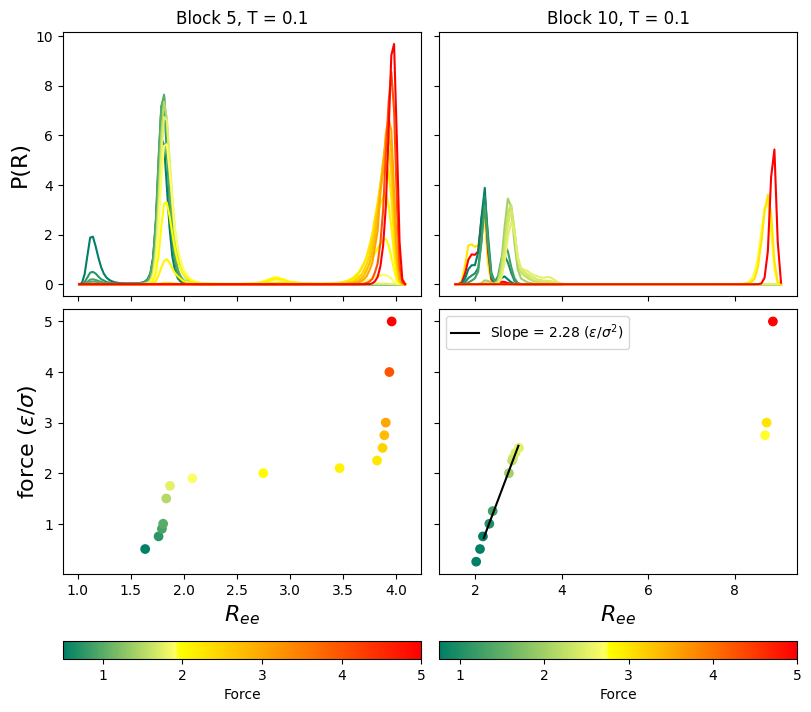

In [12]:
fig, ax = plt.subplots(nrows = 2, ncols= 2, figsize = (8, 7), sharey='row', sharex='col', layout='constrained')

#Block 
colors1 = plt.cm.summer(np.linspace(0, 1, 32))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 68))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0.5, 5)

CGT01 = lsCGTBl5[0]
Hph = []
for i in range(4, 19):
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    Hph.append(D.mean())

elastic = Hph[0:6]
modulus, intercept = plt.polyfit(elastic, CGT01.f[4:10], 1)

ax[1,0].scatter(Hph, CGT01.f[4:], color = mymap(norm(CGT01.f[4:])))
x = np.array([1.75, 1.88])
# ax[1,0].plot(x, (x*modulus+intercept)/0.1, color = 'k', label = f'Slope = {round(modulus,2)} ($\epsilon/\sigma^2$)')
ax[1,0].set_xlabel('$R_{ee}$', fontsize = 16)
ax[1,0].set_ylabel('force ($\epsilon/\sigma$)', fontsize = 16)
# ax[1,0].legend()

f_N = norm(CGT01.f[4:])

for i in range(4, 19):
    D = segRee(CGT01.ParsedRee[i], 5, 'Hydrophobic').flatten()
    rang = np.linspace(1, 4.1, 121)
    prob, xh = np.histogram(D,bins=rang, density=True)
    xh = (xh[:-1] + xh[1:]) / 2
    ax[0,0].plot(xh, prob, color = mymap(f_N[i-4]))
    
sm = mpl.cm.ScalarMappable(cmap=mymap, norm=norm)
plt.colorbar(sm, ax=ax[1,0], label='Force', orientation = 'horizontal')

#Block 10
CGT01 = lsCGTBl10[0]
colors1 = plt.cm.summer(np.linspace(0, 1, 47))
colors2 = plt.cm.autumn_r(np.linspace(0, 1, 53))

# combine them and build a new colormap
colors = np.vstack((colors1, colors2))
mymap = mcolors.LinearSegmentedColormap.from_list('my_colormap', colors)
norm = mpl.colors.Normalize(0.75, 5)
f_N = norm(CGT01.f[3:])

Hph = []
for i in range(1, 14):
    D = segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten()
    Hph.append(D.mean())
    
elastic = Hph[0:10]
modulus, intercept = plt.polyfit(elastic, CGT01.f[1:11], 1)

ax[1,1].scatter(Hph, CGT01.f[1:], color = mymap(norm(CGT01.f[1:])))
x = np.array([2.2, 3])
ax[1,1].plot(x, x*modulus+intercept, color = 'k', label = f'Slope = {round(modulus,2)} ($\epsilon/\sigma^2$)')
ax[1,1].set_xlabel('$R_{ee}$', fontsize = 16)
ax[1,1].legend()

for i in range(1, 14):
    rang = np.linspace(1.5, 9.11, 101)
    prob = np.histogram(segRee(CGT01.ParsedRee[i], 10, 'Hydrophobic').flatten(),bins=rang, density=True)[0]
    xh = (rang[:-1]+rang[1:])/2
    ax[0, 1].plot(xh, prob, color = mymap(f_N[i-3]))
plt.legend()

sm = mpl.cm.ScalarMappable(cmap=mymap, norm=norm)
plt.colorbar(sm, ax=ax[1,1], label='Force', orientation = 'horizontal')

ax[0,0].set_title('Block 5, T = 0.1')
ax[0,1].set_title('Block 10, T = 0.1')
ax[0,0].set_ylabel('P(R)', fontsize = 16)